In [9]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf

Sampling Rate: 16000
Duration (seconds): 4.5001875


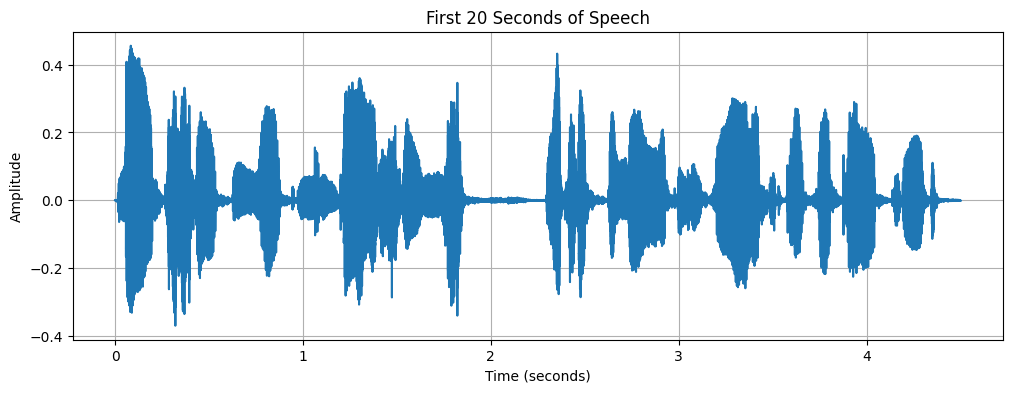

In [11]:
# Load speech file (ensure 16 kHz)
file_path = "LJ050-0274.wav"   # Replace with your file

signal, sr = sf.read(file_path)

# Convert to mono if stereo
if signal.ndim > 1:
    signal = np.mean(signal, axis=1)

# Resample if needed
if sr != 16000:
    signal = librosa.resample(signal, orig_sr=sr, target_sr=16000)
    sr = 16000

# Take first 20 seconds
signal = signal[:20 * sr]

print("Sampling Rate:", sr)
print("Duration (seconds):", len(signal)/sr)

# Plot waveform
time = np.arange(len(signal)) / sr

plt.figure(figsize=(12,4))
plt.plot(time, signal)
plt.title("First 20 Seconds of Speech")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

In [12]:
frame_length = int(0.025 * sr)   # 25 ms
frame_shift  = int(0.010 * sr)   # 10 ms

num_frames = int((len(signal) - frame_length) / frame_shift) + 1

print("Frame Length (samples):", frame_length)
print("Frame Shift (samples):", frame_shift)
print("Total Number of Frames:", num_frames)

Frame Length (samples): 400
Frame Shift (samples): 160
Total Number of Frames: 448


In [13]:
frames = np.zeros((num_frames, frame_length))

for i in range(num_frames):
    start = i * frame_shift
    end = start + frame_length
    frames[i] = signal[start:end]

print("Frames Shape:", frames.shape)

Frames Shape: (448, 400)


In [14]:
hamming_window = np.hamming(frame_length)
rect_window = np.ones(frame_length)

In [15]:
def short_time_energy(frame):
    return np.sum(frame ** 2)

def short_time_magnitude(frame):
    return np.sum(np.abs(frame))

def zero_crossing_rate(frame):
    return np.sum(np.abs(np.diff(np.sign(frame)))) / (2 * len(frame))

def autocorrelation(frame):
    return np.correlate(frame, frame, mode='full')[len(frame)-1:]

def amdf(frame):
    N = len(frame)
    result = np.zeros(N)
    for lag in range(1, N):
        result[lag] = np.sum(np.abs(frame[:-lag] - frame[lag:]))
    return result

def amsdf(frame):
    N = len(frame)
    result = np.zeros(N)
    for lag in range(1, N):
        result[lag] = np.sum((frame[:-lag] - frame[lag:])**2)
    return result

In [16]:
STE_ham = []
STM_ham = []
ZCR_ham = []
ACF_ham = []
AMDF_ham = []
AMSDF_ham = []

for frame in frames:
    w_frame = frame * hamming_window
    
    STE_ham.append(short_time_energy(w_frame))
    STM_ham.append(short_time_magnitude(w_frame))
    ZCR_ham.append(zero_crossing_rate(w_frame))
    ACF_ham.append(np.max(autocorrelation(w_frame)[1:]))  
    AMDF_ham.append(np.min(amdf(w_frame)[1:]))
    AMSDF_ham.append(np.min(amsdf(w_frame)[1:]))

STE_ham = np.array(STE_ham)
STM_ham = np.array(STM_ham)
ZCR_ham = np.array(ZCR_ham)
ACF_ham = np.array(ACF_ham)
AMDF_ham = np.array(AMDF_ham)
AMSDF_ham = np.array(AMSDF_ham)

In [17]:
STE_rect = []
STM_rect = []
ZCR_rect = []
ACF_rect = []
AMDF_rect = []
AMSDF_rect = []

for frame in frames:
    w_frame = frame * rect_window
    
    STE_rect.append(short_time_energy(w_frame))
    STM_rect.append(short_time_magnitude(w_frame))
    ZCR_rect.append(zero_crossing_rate(w_frame))
    ACF_rect.append(np.max(autocorrelation(w_frame)[1:]))
    AMDF_rect.append(np.min(amdf(w_frame)[1:]))
    AMSDF_rect.append(np.min(amsdf(w_frame)[1:]))

STE_rect = np.array(STE_rect)
STM_rect = np.array(STM_rect)
ZCR_rect = np.array(ZCR_rect)
ACF_rect = np.array(ACF_rect)
AMDF_rect = np.array(AMDF_rect)
AMSDF_rect = np.array(AMSDF_rect)

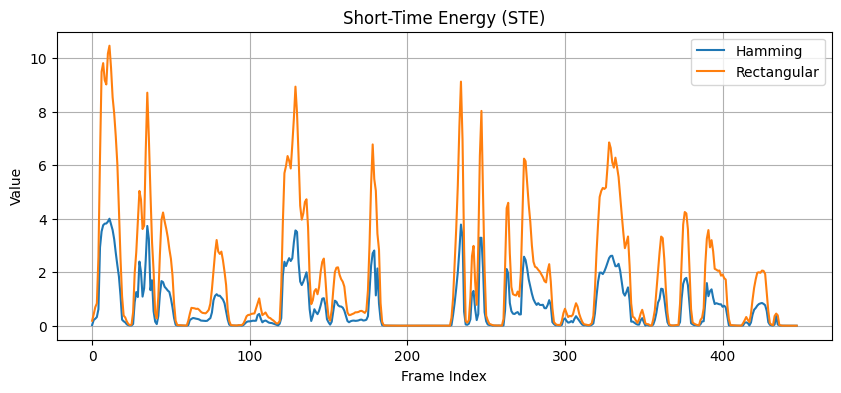

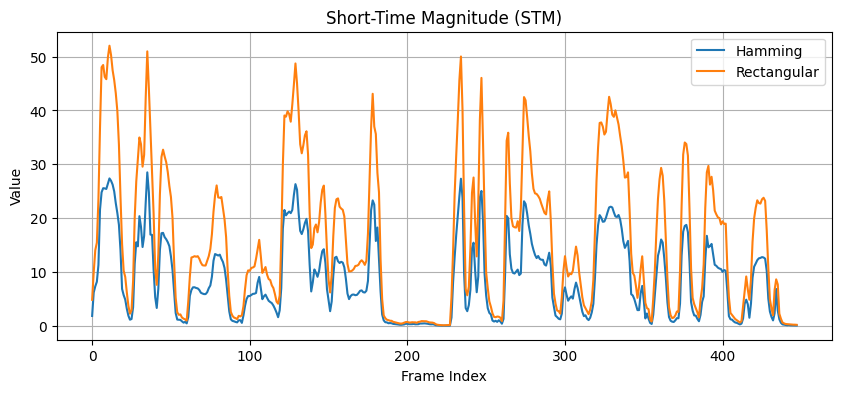

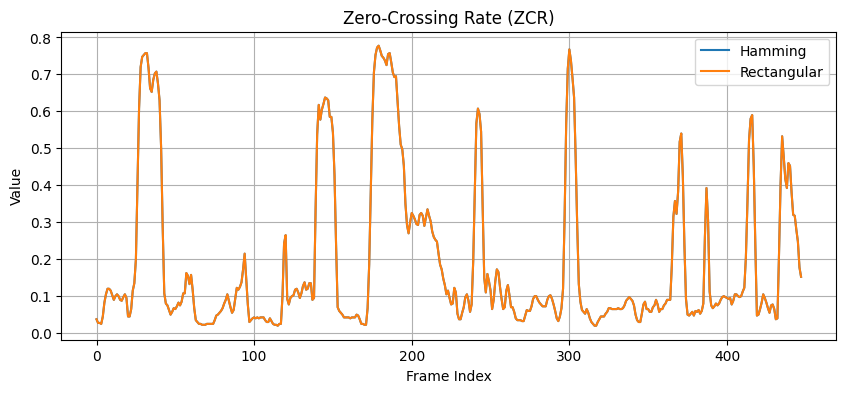

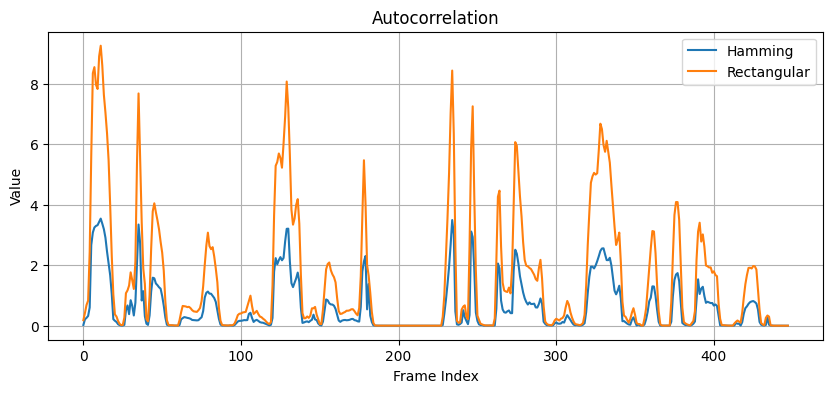

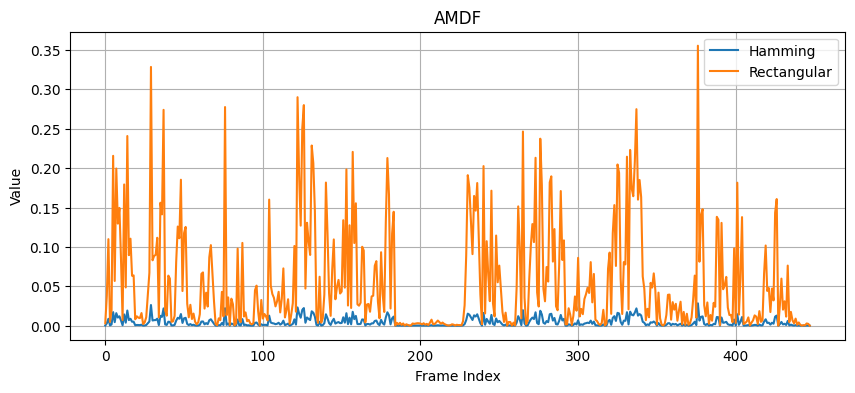

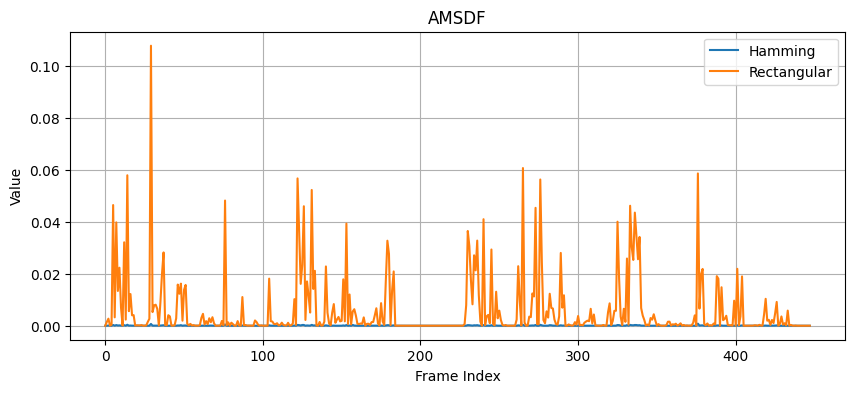

In [18]:
frame_axis = np.arange(num_frames)

def plot_feature(feature_ham, feature_rect, title):
    plt.figure(figsize=(10,4))
    plt.plot(frame_axis, feature_ham, label="Hamming")
    plt.plot(frame_axis, feature_rect, label="Rectangular")
    plt.title(title)
    plt.xlabel("Frame Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid()
    plt.show()

plot_feature(STE_ham, STE_rect, "Short-Time Energy (STE)")
plot_feature(STM_ham, STM_rect, "Short-Time Magnitude (STM)")
plot_feature(ZCR_ham, ZCR_rect, "Zero-Crossing Rate (ZCR)")
plot_feature(ACF_ham, ACF_rect, "Autocorrelation")
plot_feature(AMDF_ham, AMDF_rect, "AMDF")
plot_feature(AMSDF_ham, AMSDF_rect, "AMSDF")

In [19]:
# Periodicity detection thresholds
acf_threshold = 0.3 * np.max(ACF_ham)
amdf_threshold = np.mean(AMDF_ham)
amsdf_threshold = np.mean(AMSDF_ham)

periodic_frames = []
aperiodic_frames = []

for i in range(num_frames):
    
    acf_val = ACF_ham[i]
    amdf_val = AMDF_ham[i]
    amsdf_val = AMSDF_ham[i]
    
    # Periodic condition:
    # High autocorrelation peak AND
    # Low AMDF and AMSDF values
    
    if (acf_val > acf_threshold) and \
       (amdf_val < amdf_threshold) and \
       (amsdf_val < amsdf_threshold):
        
        periodic_frames.append(i)
    else:
        aperiodic_frames.append(i)

print("Number of Periodic (Voiced) Frames:", len(periodic_frames))
print("Number of Aperiodic (Unvoiced) Frames:", len(aperiodic_frames))

Number of Periodic (Voiced) Frames: 32
Number of Aperiodic (Unvoiced) Frames: 416


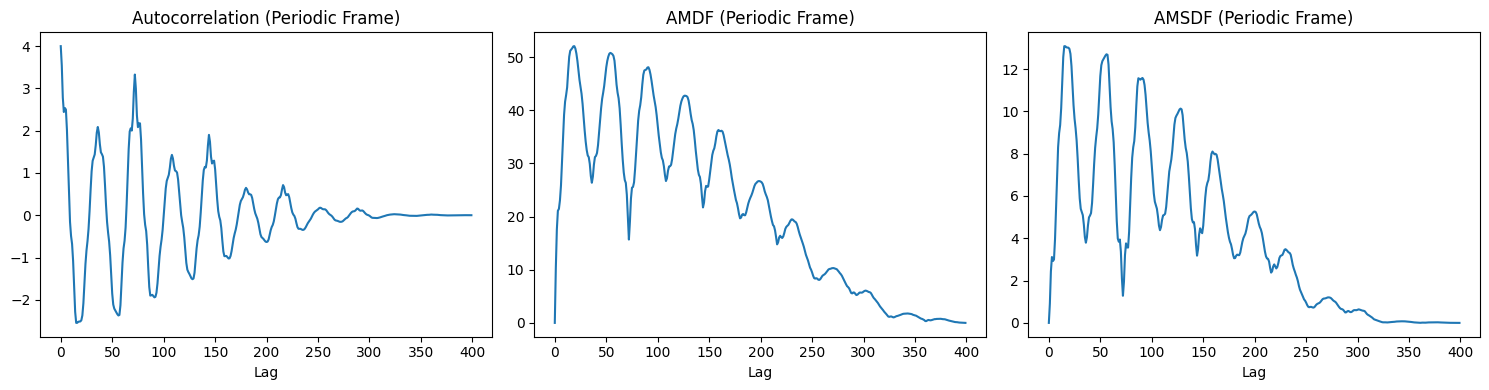

In [20]:
# Select one periodic frame (if exists)
if len(periodic_frames) > 0:
    
    idx = periodic_frames[0]
    frame = frames[idx] * hamming_window
    
    acf = autocorrelation(frame)
    amdf_val = amdf(frame)
    amsdf_val = amsdf(frame)
    
    lags = np.arange(len(acf))
    
    plt.figure(figsize=(15,4))
    
    plt.subplot(1,3,1)
    plt.plot(lags, acf)
    plt.title("Autocorrelation (Periodic Frame)")
    plt.xlabel("Lag")
    
    plt.subplot(1,3,2)
    plt.plot(lags, amdf_val)
    plt.title("AMDF (Periodic Frame)")
    plt.xlabel("Lag")
    
    plt.subplot(1,3,3)
    plt.plot(lags, amsdf_val)
    plt.title("AMSDF (Periodic Frame)")
    plt.xlabel("Lag")
    
    plt.tight_layout()
    plt.show()

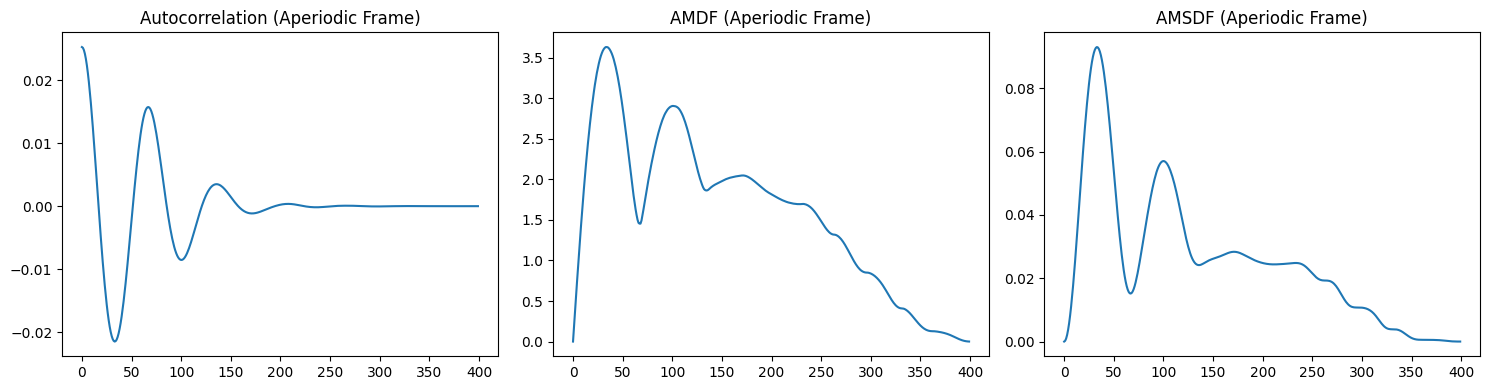

In [21]:
if len(aperiodic_frames) > 0:
    
    idx = aperiodic_frames[0]
    frame = frames[idx] * hamming_window
    
    acf = autocorrelation(frame)
    amdf_val = amdf(frame)
    amsdf_val = amsdf(frame)
    
    lags = np.arange(len(acf))
    
    plt.figure(figsize=(15,4))
    
    plt.subplot(1,3,1)
    plt.plot(lags, acf)
    plt.title("Autocorrelation (Aperiodic Frame)")
    
    plt.subplot(1,3,2)
    plt.plot(lags, amdf_val)
    plt.title("AMDF (Aperiodic Frame)")
    
    plt.subplot(1,3,3)
    plt.plot(lags, amsdf_val)
    plt.title("AMSDF (Aperiodic Frame)")
    
    plt.tight_layout()
    plt.show()

In [22]:
pitch_periods = []
pitch_frequencies = []

for idx in periodic_frames:
    
    frame = frames[idx] * hamming_window
    acf = autocorrelation(frame)
    
    # Ignore zero lag
    acf[0] = 0
    
    # Find first prominent peak
    peak_lag = np.argmax(acf)
    
    if peak_lag > 0:
        pitch_period = peak_lag
        pitch_frequency = sr / pitch_period
        
        pitch_periods.append(pitch_period)
        pitch_frequencies.append(pitch_frequency)

# Convert to numpy
pitch_periods = np.array(pitch_periods)
pitch_frequencies = np.array(pitch_frequencies)

print("Average Pitch Period (samples):", np.mean(pitch_periods))
print("Average Pitch Frequency (Hz):", np.mean(pitch_frequencies))

Average Pitch Period (samples): 6.5625
Average Pitch Frequency (Hz): 13006.488380041012
